# Versao 7 - Comparacao entre LSTM Profunda e Baselines

## Objetivo deste notebook

Um erro muito comum em projetos iniciais e treinar uma rede neural sem compará-la com modelos mais simples. Este notebook existe justamente para evitar esse problema.

Aqui vamos treinar baselines tabulares com base em **estatisticas agregadas de cada serie** e compará-las com a `LSTM` profunda proposta na `versao7`:

- `RandomForest`
- `XGBoost` (somente se estiver instalado no ambiente)

## Por que isso e importante?

Porque, em muitos problemas, uma baseline simples:

- treina mais rapido;
- e mais facil de interpretar;
- pode performar surpreendentemente bem.

Se a `LSTM` nao superar uma baseline simples, isso e um sinal pedagogicamente valioso: talvez a representacao, o treino ou a propria necessidade de um modelo sequencial precisem ser revistos.

Este notebook, portanto, nao serve apenas para "medir quem ganhou". Ele serve para interpretar por que um modelo pode ter superado o outro e o que isso ensina sobre o problema.

Como a `versao7` nasce de uma hipotese de melhoria, a pergunta experimental passa a ser:

- a `LSTM` profunda conseguiu reduzir o gap para o `RandomForest`?
- em quais classes ela melhorou mais?
- ainda vale a pena manter a baseline tabular como referencia dominante?

## Sintese Numerica Da Ultima Execucao

A execucao mais recente da `versao7` produziu o seguinte quadro no conjunto de teste:

| Modelo | Accuracy | Macro-F1 | Balanced Accuracy |
| --- | ---: | ---: | ---: |
| `LSTM v6` | `0.9433` | `0.9185` | `0.9367` |
| `LSTM profunda v7` | `0.9104` | `0.8964` | `0.9191` |
| `RandomForest` | `0.9851` | `0.9811` | `0.9744` |
| `XGBoost` | `0.9821` | `0.9791` | `0.9733` |

Leitura orientada pelos numeros:

- a `LSTM` profunda da `versao7` nao melhorou a `LSTM` da `versao6`; houve variacao de `-0.0328` em `accuracy`, `-0.0221` em `macro-F1` e `-0.0176` em `balanced accuracy`
- em validacao, o `XGBoost` foi novamente o melhor baseline em `macro-F1` (`0.9796`) e `balanced accuracy` (`0.9775`)
- em teste, o `RandomForest` continuou liderando, com pequena vantagem sobre o `XGBoost`
- portanto, a hipotese de que apenas aumentar a profundidade recorrente reduziria o gap para as baselines nao foi confirmada nesta execucao

In [12]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Este bloco torna o notebook robusto ao diretorio atual.
# Se o notebook estiver sendo executado de dentro de `versao7`,
# o projeto real estara um nivel acima.
ROOT = Path.cwd().resolve()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao7" else ROOT

# Adicionamos a raiz do projeto ao sys.path para conseguir importar
# `versao7.pipeline_v7` e demais modulos auxiliares.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [13]:
from versao7.pipeline_v7 import (
    build_metrics_table,
    load_bundle,
    load_split_arrays,
    plot_confusion_matrix_for_predictions,
    run_baseline_suite,
)

RUN_NAME = "classificacao_v7_lstm_profunda"
RUN_DIR = PROJECT_ROOT / "artifacts" / "reports_v7" / RUN_NAME
BASELINE_OUTPUT_DIR = RUN_DIR / "baselines"
LSTM_OUTPUT_DIR = RUN_DIR / "lstm"

bundle = load_bundle(RUN_DIR / "bundle_v7.json")
train_arrays = load_split_arrays(RUN_DIR / "train_arrays.npz")
val_arrays = load_split_arrays(RUN_DIR / "validation_arrays.npz")
test_arrays = load_split_arrays(RUN_DIR / "test_arrays.npz")

## Execucao das baselines

Diferentemente da `LSTM`, as baselines nao usam a sequencia completa passo a passo. Em vez disso, usam um vetor de estatisticas agregadas da serie (`X_tab`), como:

- media;
- desvio-padrao;
- minimo;
- maximo;
- mediana;
- primeiro valor;
- ultimo valor;
- inclinacao temporal;
- media das variacoes absolutas.

Essa e uma forma muito comum de transformar series temporais em tabelas para modelos classicos.

In [14]:
baseline_results = run_baseline_suite(
    X_train=train_arrays["X_tab"],
    y_train=train_arrays["y"],
    X_val=val_arrays["X_tab"],
    y_val=val_arrays["y"],
    X_test=test_arrays["X_tab"],
    y_test=test_arrays["y"],
    class_labels=bundle.class_labels,
    output_dir=BASELINE_OUTPUT_DIR,
)

baseline_results.keys()

dict_keys(['random_forest', 'xgboost'])

In [15]:
# Montamos uma tabela de comparacao das baselines.
metrics_payload = {}
for model_name, payload in baseline_results.items():
    if payload["available"]:
        metrics_payload[f"{model_name}_validation"] = payload["validation"]
        metrics_payload[f"{model_name}_test"] = payload["test"]

baseline_table = build_metrics_table(metrics_payload)
display(baseline_table)

# O XGBoost e opcional. Se ele nao estiver instalado, mostramos isso explicitamente.
if not baseline_results["xgboost"]["available"]:
    print(baseline_results["xgboost"]["message"])

,modelo,accuracy,macro_f1,balanced_accuracy
0,random_forest_test,0.985075,0.981135,0.974442
1,xgboost_validation,0.979042,0.979610,0.977456
2,xgboost_test,0.982090,0.979053,0.973318
3,random_forest_validation,0.982036,0.972616,0.961391


In [16]:
# Quantificamos tambem o espaco tabular usado pelas baselines.
# Isso e importante porque o RandomForest nao esta vendo apenas
# "menos informacao"; ele esta vendo uma representacao diferente.
baseline_feature_summary = pd.DataFrame(
    {
        "item": [
            "colunas temporais de origem",
            "estatisticas por coluna",
            "atributos finais em X_tab",
        ],
        "valor": [
            len(bundle.selected_columns),
            len(bundle.statistical_feature_names) // len(bundle.selected_columns),
            len(bundle.statistical_feature_names),
        ],
    }
)
display(baseline_feature_summary)

,item,valor
0,colunas temporais de origem,18
1,estatisticas por coluna,9
2,atributos finais em X_tab,162


In [17]:
# Agora tentamos carregar as metricas da LSTM para comparar tudo
# no mesmo quadro. Se o notebook 3 ainda nao tiver sido executado,
# apenas avisamos o usuario.
lstm_metrics_path = LSTM_OUTPUT_DIR / "lstm_test_metrics.json"
lstm_validation_metrics_path = LSTM_OUTPUT_DIR / "lstm_validation_metrics.json"
lstm_report_path = LSTM_OUTPUT_DIR / "lstm_test_classification_report.csv"

comparison_rows = []
lstm_metrics = None
lstm_validation_metrics = None
lstm_report_df = None
if lstm_metrics_path.exists():
    lstm_metrics = json.loads(lstm_metrics_path.read_text(encoding="utf-8"))
    lstm_validation_metrics = json.loads(lstm_validation_metrics_path.read_text(encoding="utf-8"))
    lstm_report_df = pd.read_csv(lstm_report_path)
    comparison_rows.append(
        {
            "modelo": "lstm_test",
            "accuracy": lstm_metrics["accuracy"],
            "macro_f1": lstm_metrics["macro_f1"],
            "balanced_accuracy": lstm_metrics["balanced_accuracy"],
        }
    )
else:
    print("Aviso: execute o notebook 3 antes se quiser comparar com a LSTM.")

for model_name, payload in baseline_results.items():
    if payload["available"]:
        comparison_rows.append(
            {
                "modelo": f"{model_name}_test",
                "accuracy": payload["test"]["accuracy"],
                "macro_f1": payload["test"]["macro_f1"],
                "balanced_accuracy": payload["test"]["balanced_accuracy"],
            }
        )

if comparison_rows:
    comparison_df = (
        pd.DataFrame(comparison_rows)
        .sort_values(["macro_f1", "balanced_accuracy"], ascending=False)
        .reset_index(drop=True)
    )
    display(comparison_df)

if lstm_metrics is not None and baseline_results["random_forest"]["available"]:
    rf_test = baseline_results["random_forest"]["test"]
    rf_val = baseline_results["random_forest"]["validation"]
    delta_df = pd.DataFrame(
        {
            "metrica": ["accuracy", "macro_f1", "balanced_accuracy"],
            "lstm_validacao": [
                lstm_validation_metrics["accuracy"],
                lstm_validation_metrics["macro_f1"],
                lstm_validation_metrics["balanced_accuracy"],
            ],
            "random_forest_validacao": [
                rf_val["accuracy"],
                rf_val["macro_f1"],
                rf_val["balanced_accuracy"],
            ],
            "ganho_rf_menos_lstm_validacao": [
                rf_val["accuracy"] - lstm_validation_metrics["accuracy"],
                rf_val["macro_f1"] - lstm_validation_metrics["macro_f1"],
                rf_val["balanced_accuracy"] - lstm_validation_metrics["balanced_accuracy"],
            ],
            "lstm_teste": [
                lstm_metrics["accuracy"],
                lstm_metrics["macro_f1"],
                lstm_metrics["balanced_accuracy"],
            ],
            "random_forest_teste": [
                rf_test["accuracy"],
                rf_test["macro_f1"],
                rf_test["balanced_accuracy"],
            ],
            "ganho_rf_menos_lstm_teste": [
                rf_test["accuracy"] - lstm_metrics["accuracy"],
                rf_test["macro_f1"] - lstm_metrics["macro_f1"],
                rf_test["balanced_accuracy"] - lstm_metrics["balanced_accuracy"],
            ],
        }
    )
    display(delta_df)

,modelo,accuracy,macro_f1,balanced_accuracy
0,random_forest_test,0.985075,0.981135,0.974442
1,xgboost_test,0.982090,0.979053,0.973318
2,lstm_test,0.910448,0.896413,0.919120


,metrica,lstm_validacao,random_forest_validacao,ganho_rf_menos_lstm_validacao,lstm_teste,random_forest_teste,ganho_rf_menos_lstm_teste
0,accuracy,0.925150,0.982036,0.056886,0.910448,0.985075,0.074627
1,macro_f1,0.899706,0.972616,0.072909,0.896413,0.981135,0.084722
2,balanced_accuracy,0.910092,0.961391,0.051299,0.919120,0.974442,0.055322


In [18]:
# Se os artefatos da versao6 existirem, comparamos a evolucao
# da LSTM rasa para a LSTM profunda.
previous_run_dir = PROJECT_ROOT / "artifacts" / "reports_v6" / "classificacao_v6_artigo" / "lstm"
previous_metrics_path = previous_run_dir / "lstm_test_metrics.json"

if lstm_metrics is not None and previous_metrics_path.exists():
    previous_metrics = json.loads(previous_metrics_path.read_text(encoding="utf-8"))
    evolution_df = pd.DataFrame(
        {
            "metrica": ["accuracy", "macro_f1", "balanced_accuracy"],
            "lstm_v6_teste": [
                previous_metrics["accuracy"],
                previous_metrics["macro_f1"],
                previous_metrics["balanced_accuracy"],
            ],
            "lstm_v7_teste": [
                lstm_metrics["accuracy"],
                lstm_metrics["macro_f1"],
                lstm_metrics["balanced_accuracy"],
            ],
            "ganho_v7_menos_v6": [
                lstm_metrics["accuracy"] - previous_metrics["accuracy"],
                lstm_metrics["macro_f1"] - previous_metrics["macro_f1"],
                lstm_metrics["balanced_accuracy"] - previous_metrics["balanced_accuracy"],
            ],
        }
    )
    display(evolution_df)

,metrica,lstm_v6_teste,lstm_v7_teste,ganho_v7_menos_v6
0,accuracy,0.943284,0.910448,-0.032836
1,macro_f1,0.918522,0.896413,-0.022109
2,balanced_accuracy,0.936684,0.919120,-0.017564


## Comparacao visual entre a LSTM e a baseline dominante

Quando a `LSTM` ja foi executada, a comparacao mais informativa nao e apenas numerica. Tambem vale observar se os erros estao concentrados nas mesmas classes ou se cada modelo falha em regioes diferentes do problema.

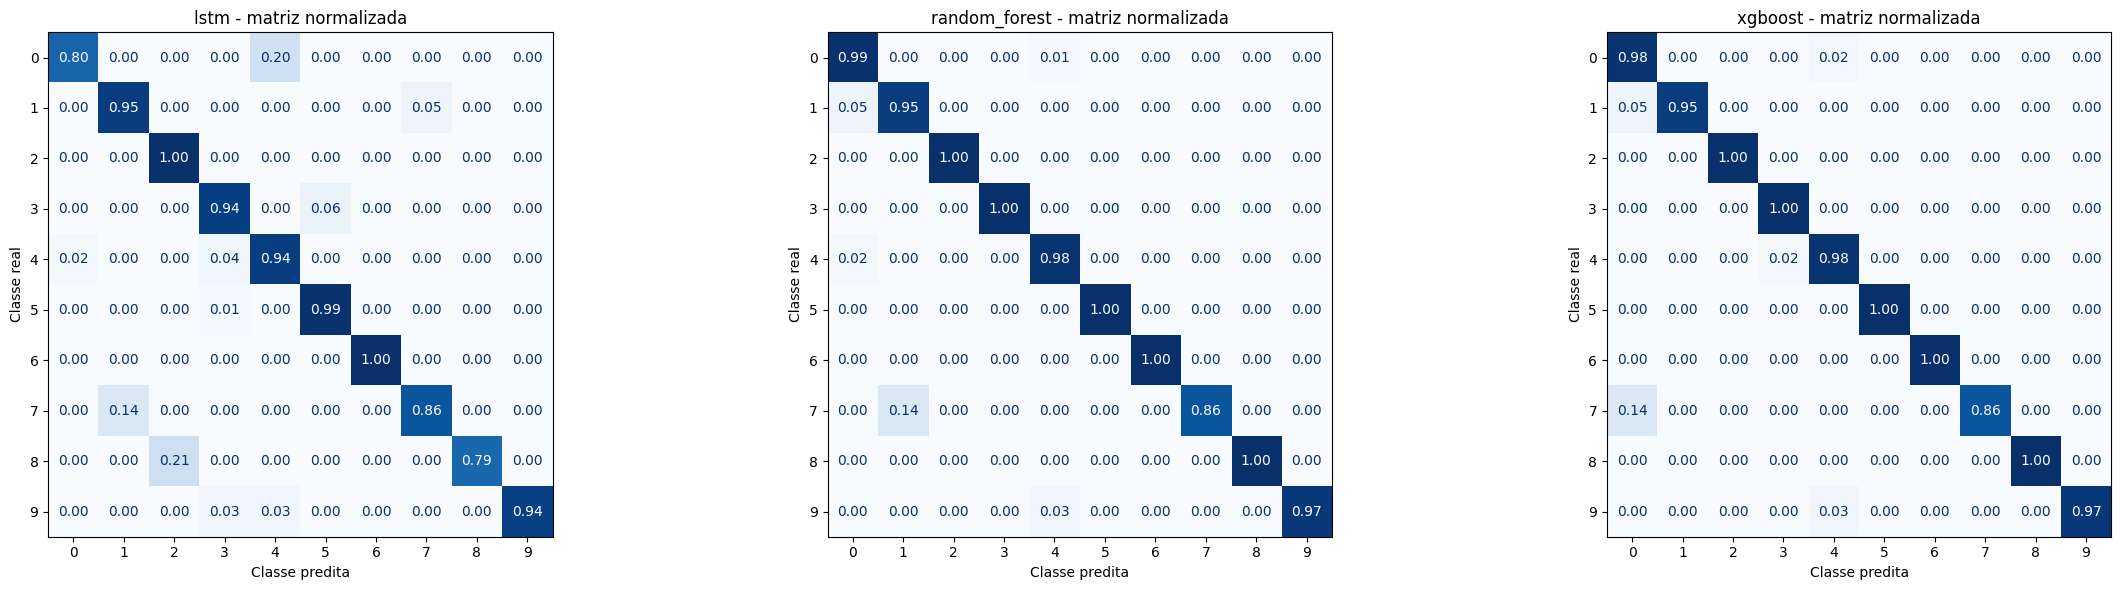

In [19]:
# Fazemos a comparacao visual no conjunto de teste.
matrix_payloads = []

if lstm_metrics is not None:
    lstm_pred_npz = np.load(LSTM_OUTPUT_DIR / "lstm_test_predictions.npz")
    matrix_payloads.append(
        {
            "nome": "lstm",
            "y_pred": lstm_pred_npz["y_pred"],
        }
    )

for model_name, payload in baseline_results.items():
    if payload["available"]:
        matrix_payloads.append(
            {
                "nome": model_name,
                "y_pred": payload["test"]["y_pred"],
            }
        )

n_models = len(matrix_payloads)
fig, axes = plt.subplots(1, n_models, figsize=(8 * n_models, 6))
if n_models == 1:
    axes = [axes]

for ax, payload in zip(axes, matrix_payloads):
    plot_confusion_matrix_for_predictions(
        test_arrays["y"],
        payload["y_pred"],
        class_labels=bundle.class_labels,
        normalize="true",
        title=f"{payload['nome']} - matriz normalizada",
        ax=ax,
    )

fig.tight_layout()
plt.show()

In [20]:
# Relatorios detalhados por classe.
for model_name, payload in baseline_results.items():
    if not payload["available"]:
        continue
    print(f"\nRelatorio por classe - {model_name} (teste)")
    display(payload["test"]["classification_report_df"])


Relatorio por classe - random_forest (teste)


,label,precision,recall,f1-score,support
0,0,0.977778,0.988764,0.983240,89.000000
1,1,0.950000,0.950000,0.950000,20.000000
2,2,1.000000,1.000000,1.000000,5.000000
3,3,1.000000,1.000000,1.000000,16.000000
4,4,0.962264,0.980769,0.971429,52.000000
5,5,1.000000,1.000000,1.000000,68.000000
6,6,1.000000,1.000000,1.000000,33.000000
7,7,1.000000,0.857143,0.923077,7.000000
8,8,1.000000,1.000000,1.000000,14.000000
9,9,1.000000,0.967742,0.983607,31.000000



Relatorio por classe - xgboost (teste)


,label,precision,recall,f1-score,support
0,0,0.977528,0.977528,0.977528,89.00000
1,1,1.000000,0.950000,0.974359,20.00000
2,2,1.000000,1.000000,1.000000,5.00000
3,3,0.941176,1.000000,0.969697,16.00000
4,4,0.944444,0.980769,0.962264,52.00000
5,5,1.000000,1.000000,1.000000,68.00000
6,6,1.000000,1.000000,1.000000,33.00000
7,7,1.000000,0.857143,0.923077,7.00000
8,8,1.000000,1.000000,1.000000,14.00000
9,9,1.000000,0.967742,0.983607,31.00000


In [21]:
# Se a LSTM estiver disponivel, fazemos uma comparacao direta por classe.
if lstm_report_df is not None and baseline_results["random_forest"]["available"]:
    rf_report_df = baseline_results["random_forest"]["test"]["classification_report_df"].copy()

    lstm_per_class = (
        lstm_report_df
        .loc[lambda df: df["label"].astype(str).isin([str(label) for label in bundle.class_labels])]
        .copy()
    )
    rf_per_class = (
        rf_report_df
        .loc[lambda df: df["label"].astype(str).isin([str(label) for label in bundle.class_labels])]
        .copy()
    )

    lstm_per_class["label"] = lstm_per_class["label"].astype(int)
    rf_per_class["label"] = rf_per_class["label"].astype(int)

    per_class_comparison = (
        lstm_per_class[["label", "precision", "recall", "f1-score", "support"]]
        .rename(
            columns={
                "precision": "lstm_precision",
                "recall": "lstm_recall",
                "f1-score": "lstm_f1",
                "support": "support",
            }
        )
        .merge(
            rf_per_class[["label", "precision", "recall", "f1-score"]].rename(
                columns={
                    "precision": "rf_precision",
                    "recall": "rf_recall",
                    "f1-score": "rf_f1",
                }
            ),
            on="label",
            how="inner",
        )
    )
    per_class_comparison["delta_f1_rf_menos_lstm"] = (
        per_class_comparison["rf_f1"] - per_class_comparison["lstm_f1"]
    )
    per_class_comparison = per_class_comparison.sort_values(
        "delta_f1_rf_menos_lstm", ascending=False
    )
    display(per_class_comparison)

,label,lstm_precision,lstm_recall,lstm_f1,support,rf_precision,rf_recall,rf_f1,delta_f1_rf_menos_lstm
2,2,0.625000,1.000000,0.769231,5.0,1.000000,1.000000,1.000000,0.230769
4,4,0.720588,0.942308,0.816667,52.0,0.962264,0.980769,0.971429,0.154762
3,3,0.789474,0.937500,0.857143,16.0,1.000000,1.000000,1.000000,0.142857
8,8,1.000000,0.785714,0.880000,14.0,1.000000,1.000000,1.000000,0.120000
0,0,0.986111,0.797753,0.881988,89.0,0.977778,0.988764,0.983240,0.101253
7,7,0.857143,0.857143,0.857143,7.0,1.000000,0.857143,0.923077,0.065934
9,9,1.000000,0.935484,0.966667,31.0,1.000000,0.967742,0.983607,0.016940
5,5,0.985294,0.985294,0.985294,68.0,1.000000,1.000000,1.000000,0.014706
1,1,0.950000,0.950000,0.950000,20.0,0.950000,0.950000,0.950000,0.000000
6,6,1.000000,1.000000,1.000000,33.0,1.000000,1.000000,1.000000,0.000000


In [22]:
# Esta celula sintetiza a interpretacao final em linguagem mais explicativa.
if lstm_metrics is not None and baseline_results["random_forest"]["available"]:
    rf_test = baseline_results["random_forest"]["test"]
    strongest_gap = per_class_comparison.iloc[0]

    print("Interpretacao ampliada da comparacao final")
    print()
    print(
        f"No conjunto de teste, a LSTM obteve accuracy = {lstm_metrics['accuracy']:.4f}, "
        f"macro-F1 = {lstm_metrics['macro_f1']:.4f} e balanced accuracy = {lstm_metrics['balanced_accuracy']:.4f}."
    )
    print(
        f"No mesmo conjunto, o RandomForest alcancou accuracy = {rf_test['accuracy']:.4f}, "
        f"macro-F1 = {rf_test['macro_f1']:.4f} e balanced accuracy = {rf_test['balanced_accuracy']:.4f}."
    )
    print(
        f"Isso representa um ganho de {rf_test['accuracy'] - lstm_metrics['accuracy']:.4f} em accuracy, "
        f"{rf_test['macro_f1'] - lstm_metrics['macro_f1']:.4f} em macro-F1 e "
        f"{rf_test['balanced_accuracy'] - lstm_metrics['balanced_accuracy']:.4f} em balanced accuracy, "
        "sempre a favor do RandomForest."
    )
    print()
    print(
        "Em termos metodologicos, o resultado sugere que as estatisticas agregadas de cada serie "
        "foram extremamente informativas para separar as classes. Em outras palavras, o baseline "
        "tabular recebeu uma representacao condensada e muito discriminativa do problema."
    )
    print(
        "Ja a LSTM recebeu a sequencia reamostrada e precisou aprender internamente, a partir dos dados crus, "
        "resumos equivalentes a media, nivel, variabilidade, tendencia e transicoes de estado. "
        "Isso e mais flexivel, mas tambem mais dificil."
    )
    print()
    print(
        f"A maior vantagem por classe apareceu na classe {int(strongest_gap['label'])}, "
        f"em que o ganho de F1 do RandomForest sobre a LSTM foi de "
        f"{strongest_gap['delta_f1_rf_menos_lstm']:.4f}."
    )
    print(
        "Por isso, a conclusao nao deve ser 'redes neurais sao piores', e sim: "
        "'nesta configuracao, a baseline tabular explorou melhor o sinal disponivel'."
    )
    print(
        "Essa leitura motiva diretamente a versao seguinte do projeto, na qual propomos uma LSTM "
        "mais profunda e com maior capacidade de abstracao temporal."
    )

Interpretacao ampliada da comparacao final

No conjunto de teste, a LSTM obteve accuracy = 0.9104, macro-F1 = 0.8964 e balanced accuracy = 0.9191.
No mesmo conjunto, o RandomForest alcancou accuracy = 0.9851, macro-F1 = 0.9811 e balanced accuracy = 0.9744.
Isso representa um ganho de 0.0746 em accuracy, 0.0847 em macro-F1 e 0.0553 em balanced accuracy, sempre a favor do RandomForest.

Em termos metodologicos, o resultado sugere que as estatisticas agregadas de cada serie foram extremamente informativas para separar as classes. Em outras palavras, o baseline tabular recebeu uma representacao condensada e muito discriminativa do problema.
Ja a LSTM recebeu a sequencia reamostrada e precisou aprender internamente, a partir dos dados crus, resumos equivalentes a media, nivel, variabilidade, tendencia e transicoes de estado. Isso e mais flexivel, mas tambem mais dificil.

A maior vantagem por classe apareceu na classe 2, em que o ganho de F1 do RandomForest sobre a LSTM foi de 0.2308.
Por i

## Leitura didatica final

A leitura final deste notebook deve ser feita sempre com base nos numeros efetivamente produzidos na sua execucao.

Esse diagnostico e cientificamente valioso por tres motivos:

- evita a conclusao apressada de que modelos profundos sao sempre superiores;
- mostra que a engenharia de atributos ainda e uma baseline muito forte em series temporais industriais, com `RandomForest` e `XGBoost` ambos acima das redes recorrentes avaliadas;
- permite verificar se o aumento de profundidade da `LSTM` realmente trouxe ganho mensuravel.

Nesta execucao, a `LSTM` profunda nao superou a `versao6`, e as duas baselines tabulares permaneceram a frente, com pequena vantagem final do `RandomForest` sobre o `XGBoost` no teste. Isso sugere que, para este problema, aumentar profundidade recorrente sem mudar a estrategia de representacao nao foi suficiente para deslocar a lideranca das abordagens tabulares agregadas.